# Simple Linear Regression
Linear models were always among the basic statistical models to start with in predictive analytics and data mining. They also have been a prominent and relevant tool part of the body of knowledge of statistics, economics, and many other quantitative subjects.
We will use Python to evaluate the statistical outputs of a linear model, providing information about the different statistical tests used.


## Setting up your working environment



In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

In [3]:
%matplotlib inline

## Representing a normal distribution
In the real world, normally distributed variables are rare.
Consequently, it is important to verify that the actual distribution we are working on is not so far from an ideal normal one or it will pose problems in your expected results.

Normally distributed variables are an important requirement for statistical models (such as mean and, in certain aspects, linear regression). <br>
Working with a normally distributed variable is preferable to other distributions.
A normally distributed curve is a distribution of data that is symmetric and has certain characteristics regarding its shape (a certain height and spread).

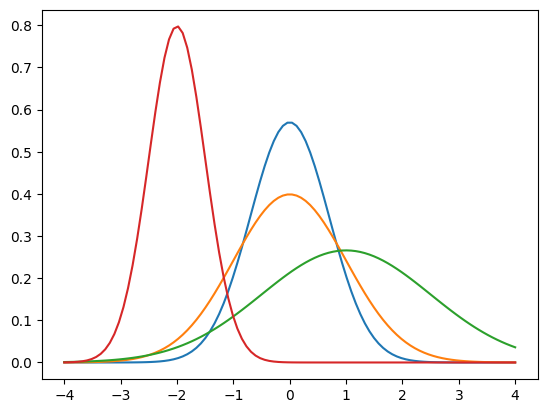

In [4]:
import numpy as np
import scipy.stats as stats
from scipy.stats import norm
import math
import matplotlib.mlab as mlab

# To Do : Describe what is happening here.

# Add in 2 more distributions lines and describe the values added
# Describe the current values of the distributions in the graph

x = np.linspace(-4,4,100)
for mean, variance in [(0,0.7),(0,1),(1,1.5),(-2,0.5)]:

    # using the probability denisty function of the mean & variance supplied with the norm.pdf functions
    plt.plot(x, norm.pdf(x,mean,variance))
plt.show()

# **To Do : Describe what is happening here.**
1. x = np.linspace(-4,4,100) cerates 100 numbers between -4 and 4.

2. for mean, variance in [(0,0.7),(0,1),(1,1.5),(-2,0.5)]:
loop where mean is center of the bell, variance is how wide or narrow the bell is

3. norm.pdf(x,mean,variance)) calculates the height of the bell curve for each x value

4. plt.plot(x, norm.pdf(x,mean,variance)) draws multiple bel curves on the same graph

#Add in 2 more distributions lines and describe the values added

Vales added:
1. (2.5, 2) - blue. Center at 2.5 (shifted to the right). Large spread which means very wide and flatter than the others in the previous graph. This indicates that the data is highly spread out from the mean.
2. (-3,0.2) - yellow. Center at -3 (shifted to the left). Very small standard deviation, the bell is very tall and narrow compared to the other curves in the prevoius graph. This means most values are very close to the mean.

#Describe the current values of the distributions in the graph

1. (0, 0.7) - blue bell.
Center at 0.
Small spread which means tall and narrow.
Data is concentrated near the mean.

2. (0, 1) - yellow bell.
Center at 0.
Wider than the first curve.
Represents a standard normal shape.

3. (1, 1.5) - green bell.
Center at 1(moved right).
Large spread which means flatter and wider.
Data is more spread out.

4. (-2, 0.5) - red bell.
Center at -2(shifted to the left).
Very small spread which means very tall and narrow.
Most values are close to -2.





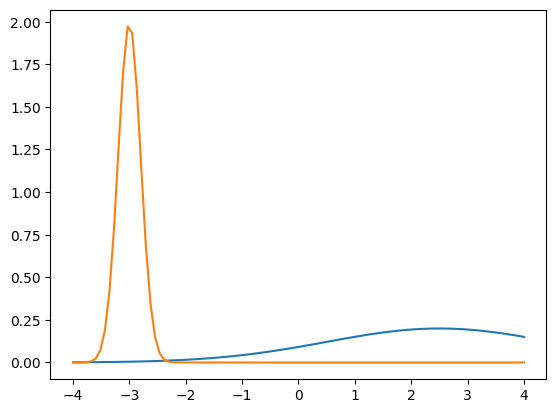

In [5]:
for mean, variance in [(2.5, 2), (-3,0.2)]:
  plt.plot(x, norm.pdf(x,mean,variance))
plt.show()

## Working with the Boston dataset
The dataset is made up of 506 census tracts of Boston from the 1970 census and it features 21 variables regarding various aspects that could impact real estate value. <br>
The target variable is the median monetary value of the houses, expressed
in thousands of USD. Among the available features, there are some fairly obvious
ones such as the number of rooms, the age of the buildings, and the crime levels in the neighborhood, and some others that are a bit less obvious, such as the pollution concentration, the availability of nearby schools, the access to highways, and the distance from employment centers.

In [7]:
boston = pd.read_csv('boston.csv')
boston.head()

,MEDV,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,24.0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98
1,21.6,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14
2,34.7,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03
3,33.4,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94
4,36.2,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33


In [8]:
boston.shape

(506, 14)

### Dataset variables - Description
**Variables in order - ** feature variables based on which we will predict the value of a house<br>
 * CRIM     per capita crime rate by town <br>
 * ZN       proportion of residential land zoned for lots over 25,000 sq.ft.<br>
 * INDUS    proportion of non-retail business acres per town<br>
 * CHAS     Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)<br>
 * NOX      nitric oxides concentration (parts per 10 million)<br>
 * RM       average number of rooms per dwelling<br>
 * AGE      proportion of owner-occupied units built prior to 1940<br>
 * DIS      weighted distances to five Boston employment centres<br>
 * RAD      index of accessibility to radial highways<br>
 * TAX      full-value property-tax rate per $10,000<br>
 * PTRATIO  pupil-teacher ratio by town<br>
 * B        1000(Bk - 0.63)^2 proportion of non-Caucasian by town<br>
 * LSTAT    % lower status of the population<br><br>

**Target variable -** The prices of the house we want to predict <br>
 * MEDV     Median value of owner-occupied homes in $1000's<br>

### Data pre-processing
Check for missing values in all the columns

In [9]:
boston.isnull().sum()

,0
MEDV,0
CRIM,0
ZN,0
INDUS,0
CHAS,0
NOX,0
RM,0
AGE,0
DIS,0
RAD,0


### Exploratory Data Analysis

#### Data Analysis

In [ ]:
boston.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   MEDV     506 non-null    float64
 1   CRIM     506 non-null    float64
 2   ZN       506 non-null    float64
 3   INDUS    506 non-null    float64
 4   CHAS     506 non-null    int64  
 5   NOX      506 non-null    float64
 6   RM       506 non-null    float64
 7   AGE      506 non-null    float64
 8   DIS      506 non-null    float64
 9   RAD      506 non-null    int64  
 10  TAX      506 non-null    int64  
 11  PTRATIO  506 non-null    float64
 12  B        506 non-null    float64
 13  LSTAT    506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [ ]:
boston.describe()

,MEDV,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,22.532806,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063
std,9.197104,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062
min,5.000000,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000
25%,17.025000,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000
50%,21.200000,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000
75%,25.000000,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000
max,50.000000,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000


#### Data Visualisation

By analysing our data we know what we are working with. There is a slight skew to the left with some outliers as seen in the histogram.

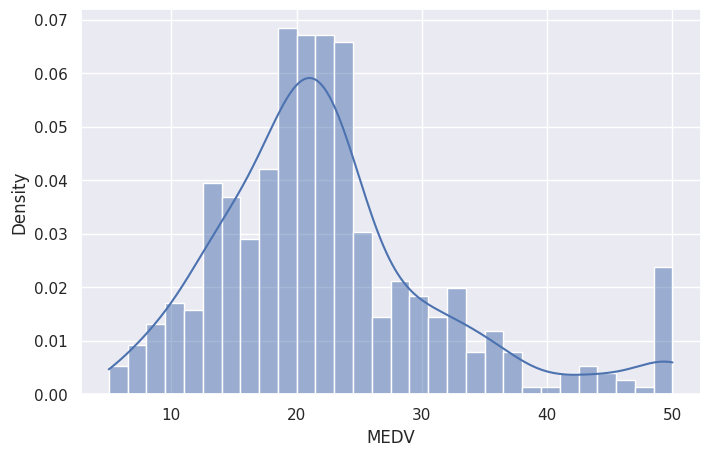

In [ ]:
# set the size of the figure
sns.set(rc={'figure.figsize':(8,5)})

# plot a histogram showing the distribution of the target/dependent values - MEDV
# "density" : it means the histogram will be normalized such that the total area under the histogram is equal to 1.
# "kde=True - kernel density estimate (KDE) plot is overlaid on top of the histogram
sns.histplot(boston['MEDV'], kde=True, stat="density", bins=30)
plt.show()

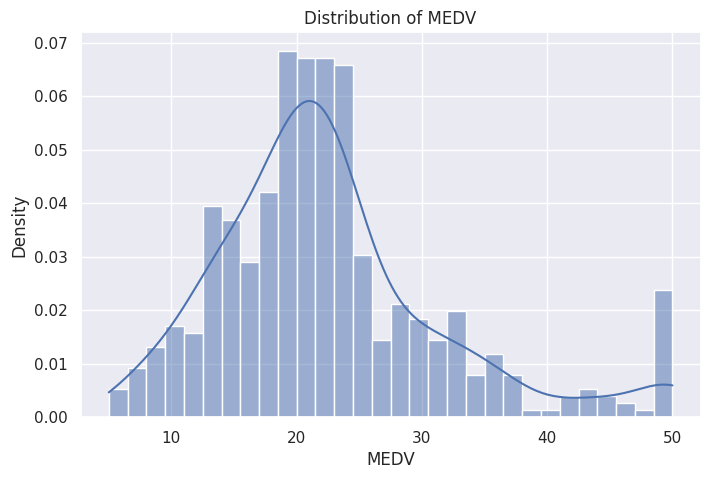

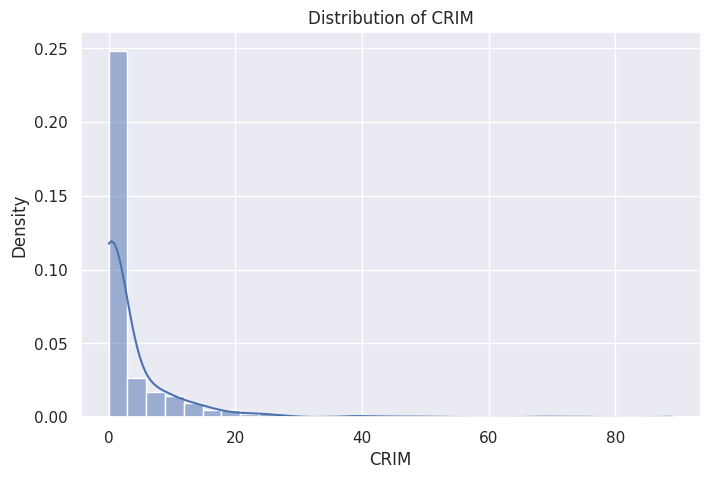

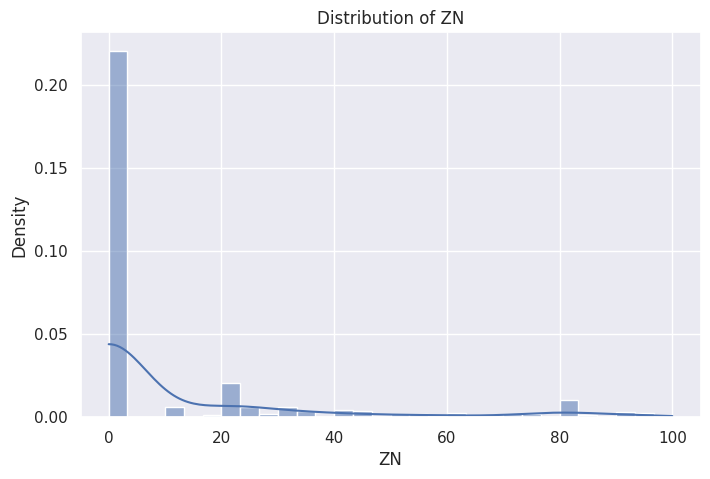

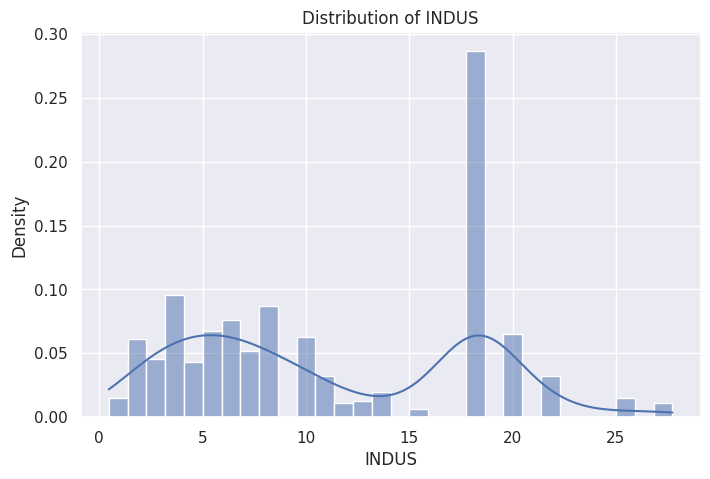

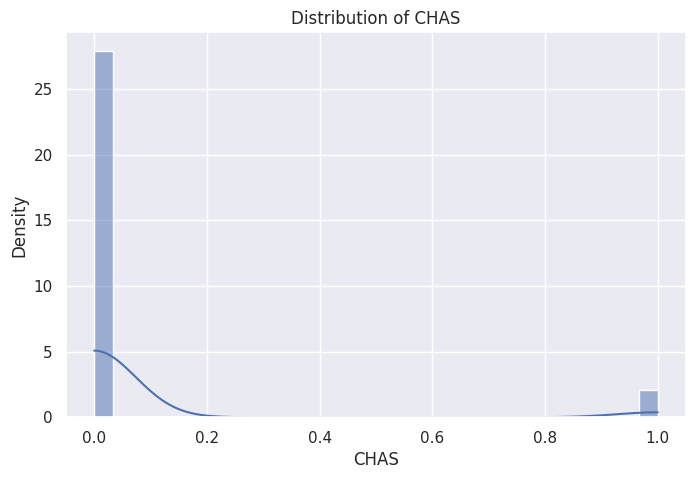

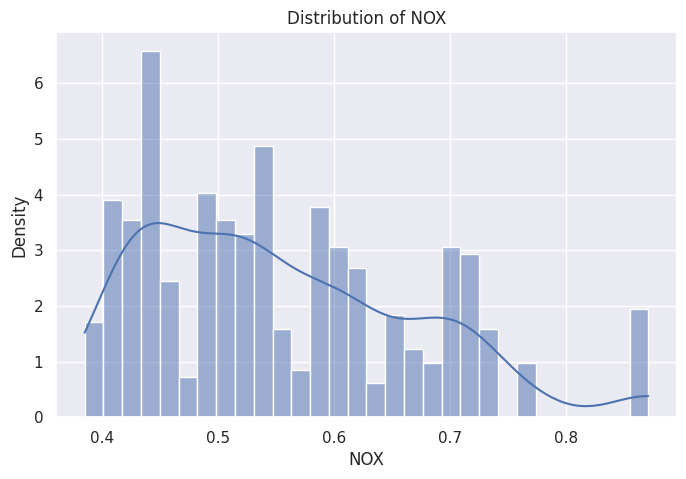

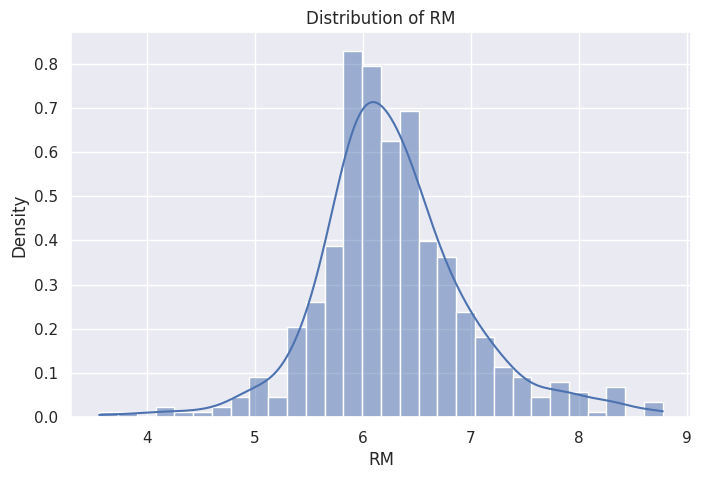

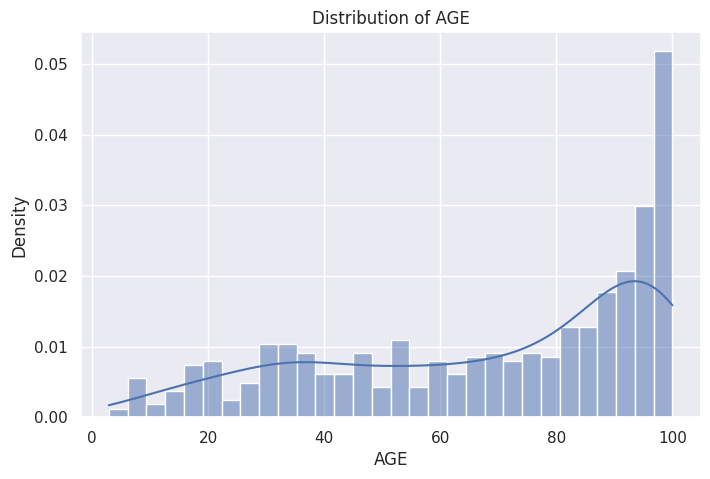

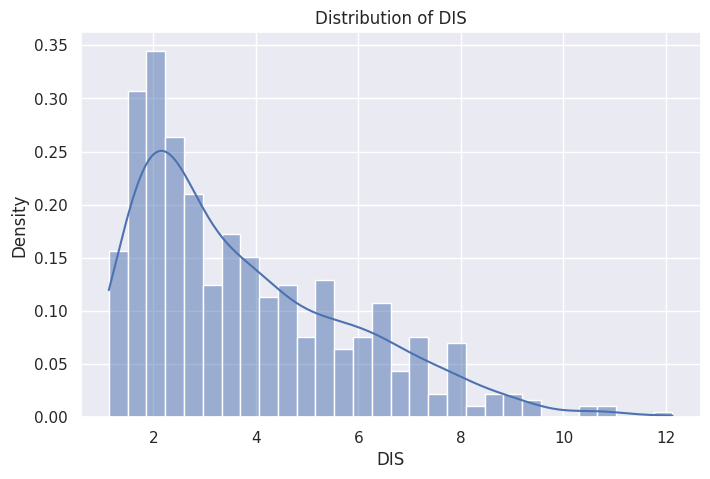

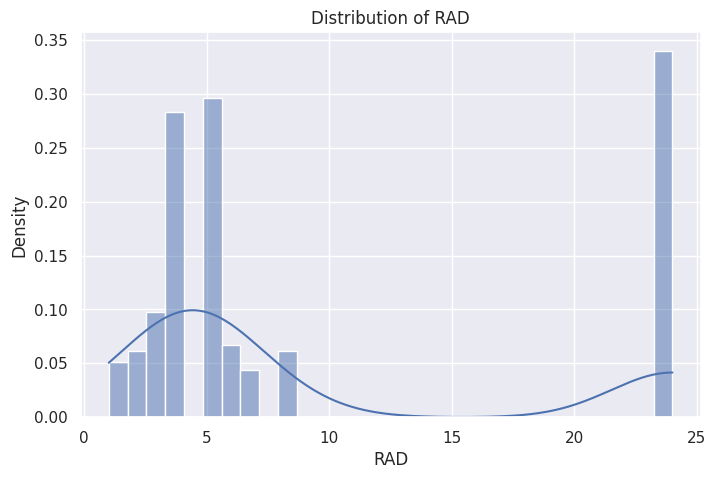

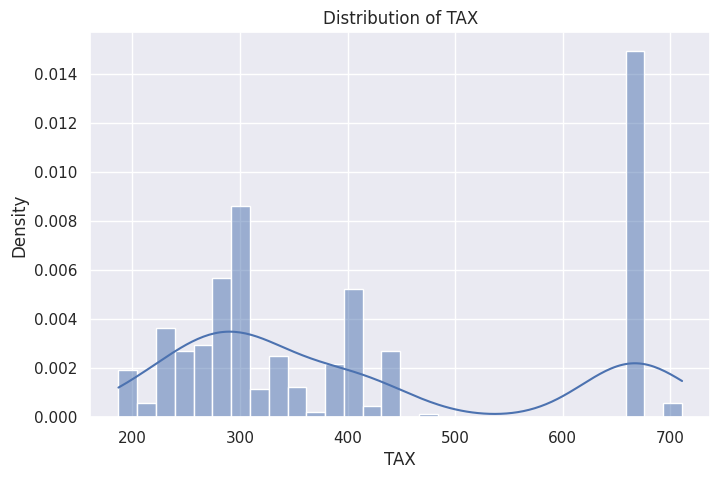

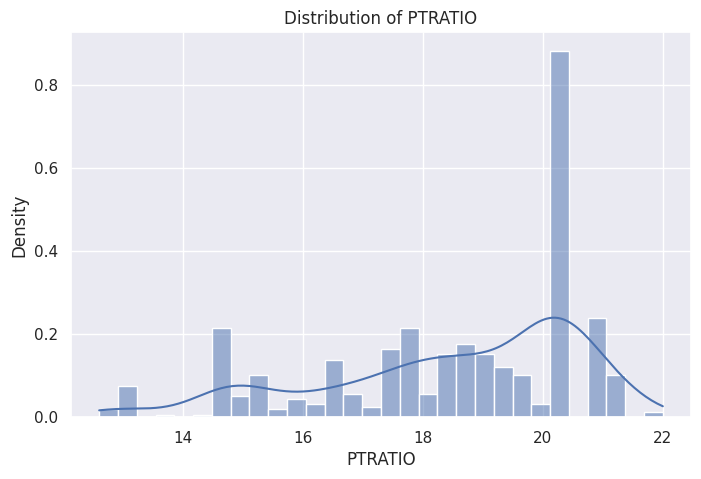

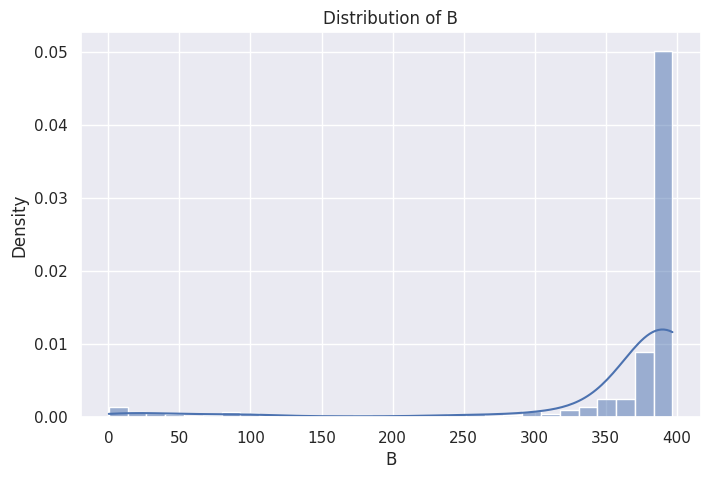

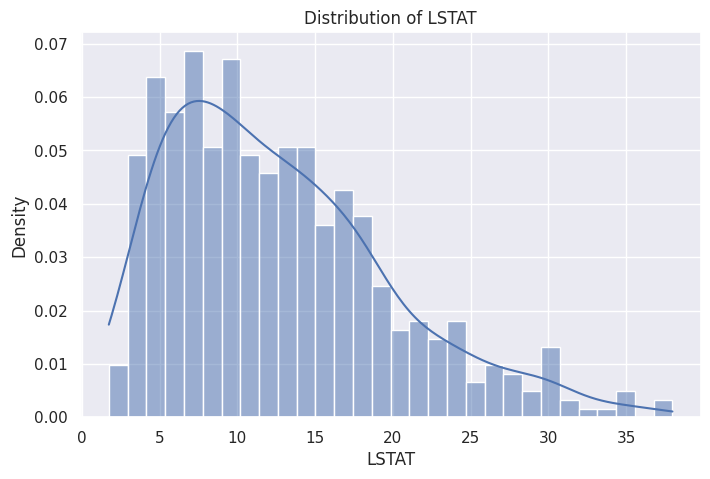

In [ ]:
# Iterate through each column in the DataFrame
for column in boston.columns:
    # Create a histogram for the current column
    plt.figure()  # Create a new figure for each histogram
    sns.histplot(boston[column], kde=True, stat="density", bins=30)
    plt.title(f'Distribution of {column}')  # Set the title of the histogram
    plt.xlabel(column)  # Set the x-axis label
    plt.ylabel('Density')  # Set the y-axis label
    plt.show()

##### Student Activity
Plot histograms for all the variables in a grid - similar to the image.

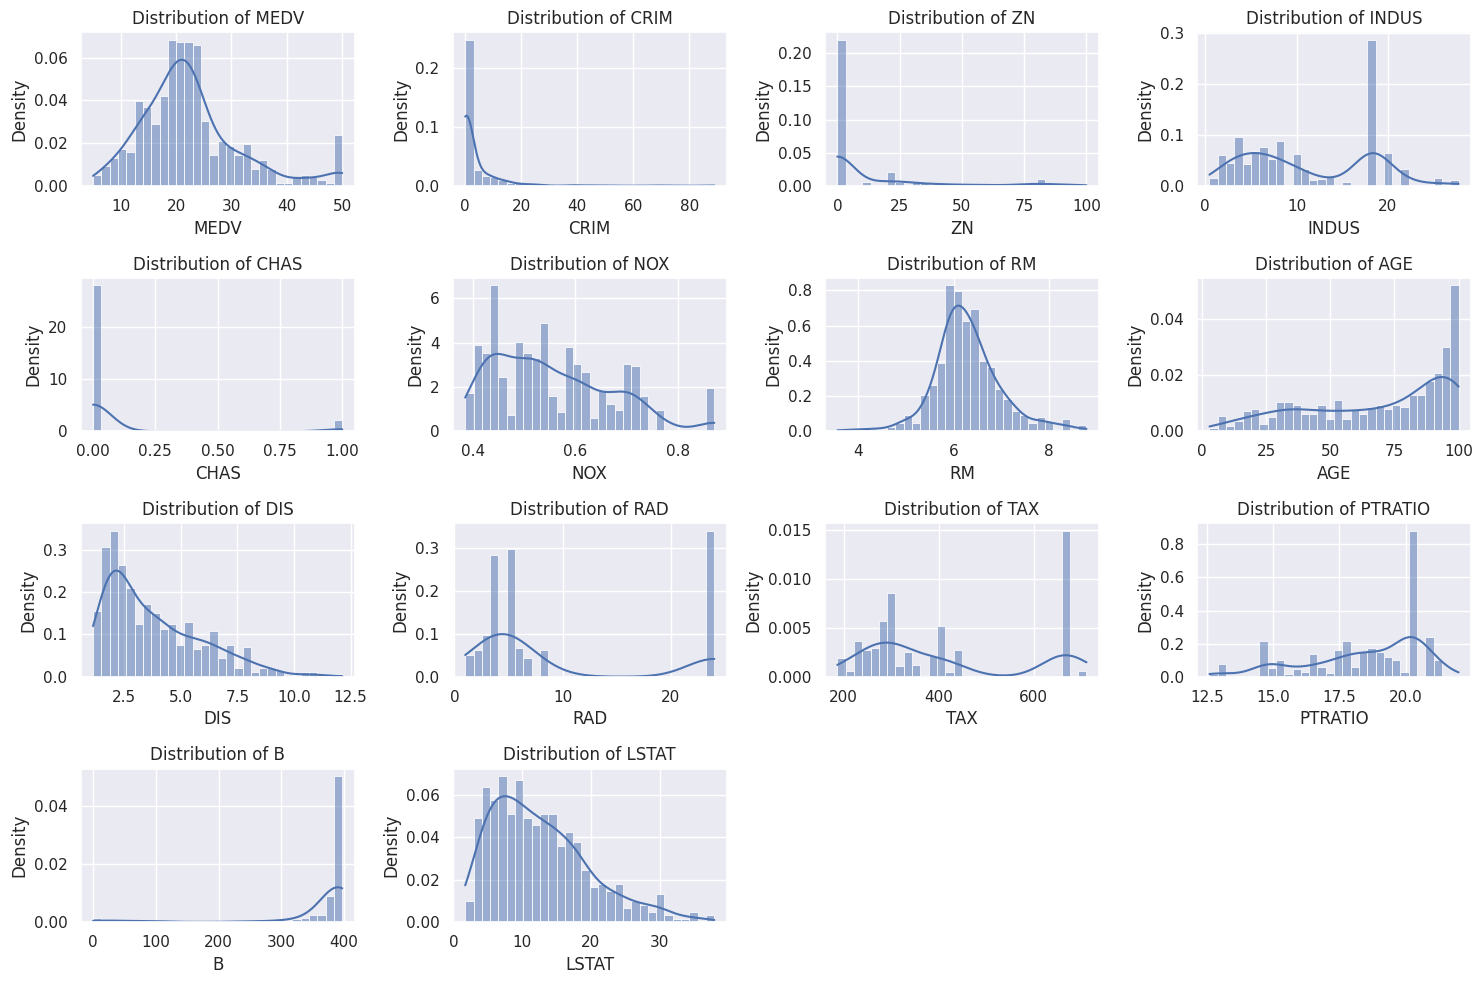

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

### code here

#### Standard Deviation
Standard Deviation is a measure of how dispersed the data is in relation to the mean.
Lets create our own function to measure Standard Deviation and compare with Numpys function

In [ ]:
def standard_deviation(variable, bias=0):
    observations = float(len(variable))
    return np.sqrt(np.sum((variable - np.mean(variable))**2) / (observations-min(bias,1)))

print ('Our function\'s result: %0.5f against Numpy\'s: %0.5f' % (standard_deviation(boston['RM']), np.std(boston['RM'])))

Our function's result: 0.70192 against Numpy's: 0.70192


Standardising : In statistical Z score standardization, you subtract from each variable its mean and then you divide the result by the standard deviation.

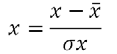

In [ ]:
def standardize(variable):
    return (variable - np.mean(variable)) / np.std(variable)

#### Correlation
Correlation: measure how much and in what direction two variables relate to each other<br>
Covariance: measures how two variables vary in tandem from their means <br>

We will get the correlation which will be a number ranging from -1 to 1. <br>
* 0 - no relation between the variables <br>
* -1 or 1 perfect relation (negative or positive)




In [ ]:
def covariance(variable_1, variable_2, bias=0):
    observations = float(len(variable_1))
    return np.sum((variable_1 - np.mean(variable_1)) * (variable_2 - np.mean(variable_2))) / (observations-min(bias,1))

def correlation(var1,var2,bias=0):
    return covariance(standardize(var1), standardize(var2),bias)

# Comparing Pearsons correlation from Scipy with our own created functions
from scipy.stats import pearsonr
print ('Our correlation estimation: %0.5f' % (correlation(boston['RM'], boston['MEDV'])))
print ('Correlation from Scipy pearsonr estimation: %0.5f' % pearsonr(boston['RM'], boston['MEDV'])[0])

#print (help(np.corrcoef))

Our correlation estimation: 0.69536
Correlation from Scipy pearsonr estimation: 0.69536


The scatterplot plots the average value for both the target and the predictor variables as dashed lines. This divides the plot into four quadrants. If we compare it with the previous covariance and correlation formulas, we can understand why the correlation value was close to 1: in the bottom-right and in top-left quadrants, there are just a few mismatching points <br><br>

A perfect match (correlation values of 1 or -1) is possible only when the points are in a straight line (and all points are therefore concentrated in the right-uppermost and left-lowermost quadrants).

Correlation is a measure of linear association, of how close to a straight line your points are. Ideally, having all your points on a single line favors a perfect mapping of your predictor variable to your target.

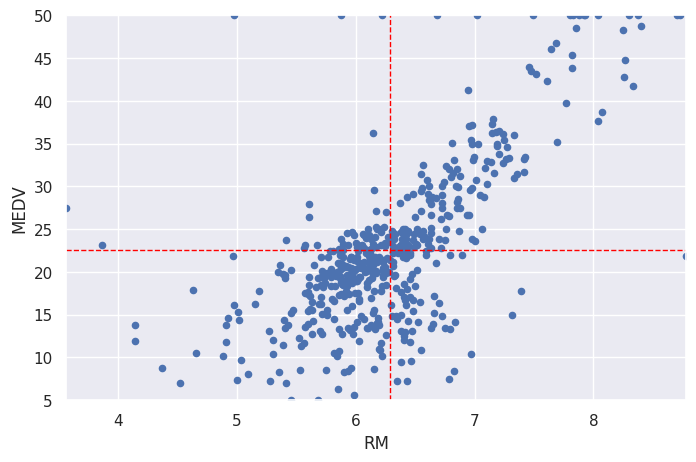

In [ ]:
# PLot these two variables
x_range = [boston['RM'].min(),boston['RM'].max()]
y_range = [boston['MEDV'].min(),boston['MEDV'].max()]
scatter_plot = boston.plot(kind='scatter', x='RM', y='MEDV', xlim=x_range, ylim=y_range)
meanY = scatter_plot.plot(x_range, [boston['MEDV'].mean(),boston['MEDV'].mean()], '--', color='red', linewidth=1)
meanX = scatter_plot.plot([boston['RM'].mean(),boston['RM'].mean()], y_range, '--', color='red', linewidth=1)

####  Correlation Matrix
Correlation: measure how much and in what direction two variables relate to each other. Values ranging from -1 to 1

In [ ]:
# compute the pair wise correlation for all columns
correlation_matrix = boston.corr().round(2)

<Axes: >

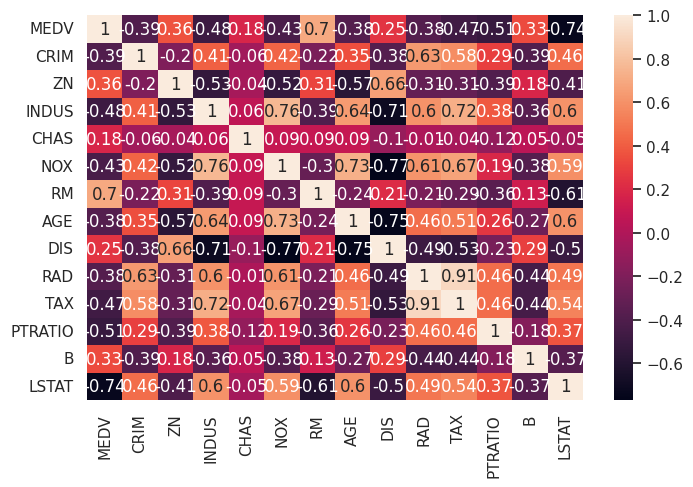

In [ ]:
# use the heatmap function from seaborn to plot the correlation matrix
# annot = True to print the values inside the square
sns.heatmap(data=correlation_matrix, annot=True)

Correlation Matrix Observations:
 * From the above coorelation plot we can see that MEDV is strongly correlated to LSTAT, RM
 * RAD and TAX are strongly correlated, so we don't include this in our features together to avoid multi-colinearity

## Linear regression in action: Statsmodels

Using the stats model the formula becomes : 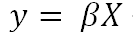

This can be interpreted as a combination of the variables in X, multiplied by its corresponding β value (β is a matrix of coefficients)

In [10]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [11]:
# define the y and X variables
y = boston['MEDV']
X = boston['RM']
# The X variable needs to be extended by a constant value (). The predictor X now contains both the predictive variable and a unit constant
X = sm.add_constant(X)

In [ ]:
X.head()

,const,RM
0,1.0,6.575
1,1.0,6.421
2,1.0,7.185
3,1.0,6.998
4,1.0,7.147


### Train the MOdel

In [12]:
# set the initialization of the linear regression calculation
linear_regression = sm.OLS(y,X)

fitted_model = linear_regression.fit()

#### Model Summary
For now, we are interested in:<br>
* R-squared: This is the coefficient of determination, a measure of how well the regression does with respect to a simple mean. A better R-squared should hint at a better model.
* F-statistic: This is a measure telling you if, from a statistical point of view, all your coefficients, apart from the bias and taken together, are different from zero. In simple words, it tells you if your regression is really better than a simple average. <br>
* coef: The estimated coefficient - describe the relationship between each independent variable and the dependent variable <br>
* std err: The standard error of the estimate of the coefficient; the larger it is, the more uncertain the estimation of the coefficient



In [13]:
fitted_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   MEDV   R-squared:                       0.484
Model:                            OLS   Adj. R-squared:                  0.483
Method:                 Least Squares   F-statistic:                     471.8
Date:                Sun, 08 Feb 2026   Prob (F-statistic):           2.49e-74
Time:                        01:10:02   Log-Likelihood:                -1673.1
No. Observations:                 506   AIC:                             3350.
Df Residuals:                     504   BIC:                             3359.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -34.6706      2.650    -13.084      0.000     -39.877     -29.465
RM             9.1021      0.419     21.722      0.000       8.279       9.925
==============================================================================
Omnibus:                      102.585   Durbin-Watson:                   0.684
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              612.449
Skew:                           0.726   Prob(JB):                    1.02e-133
Kurtosis:                       8.190   Cond. No.                         58.4
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

R-squared = 0.484 - 48.4%

0 - useless model
1 - perfect model

About half of the variation in house prices is explained by the number of rooms.

F-statistic

The value is VERY large with a tiny probability. So yes - the model is statistically useful.

intercepts don’t always have real meaning. they just help position the line correctly

9.10 means that every extra room increases the house price by about $9,100.

This gives the final equation:
Predicted price = -34.67 + 9.10 × RM

Standard Error (std err)

0.419 - very reliable estimate


The coefficients are the most important output that we can obtain from our regression model because they allow us to re-create the weighted summation that can predict our outcomes. <br>
In our example, our coefficients are: <br>
* −34.6706 for the bias (also called the intercept) <br>
* 9.1021 for the RM variable. <br>

Recalling our formula, we can plug in the numbers we obtained:

In [14]:
# The coefficient values can be obtained from:
print (fitted_model.params)
betas = np.array(fitted_model.params)
print("Betas:\n", betas)



const   -34.670621
RM        9.102109
dtype: float64
Betas:
 [-34.67062078   9.10210898]


### Predict

In [15]:
# Predicting our fitted values
fitted_values = fitted_model.predict(X)
print("fitted_values", fitted_values)

fitted_values 0      25.175746
1      23.774021
2      30.728032
3      29.025938
4      30.382152
         ...    
501    25.339584
502    21.034286
503    28.825691
504    27.169108
505    20.215096
Length: 506, dtype: float64


In [16]:
# Lets predct the value of a house with 5 bedrooms

RM = 5
Xp = np.array([1,RM])
print ("Our model predicts if RM = %f the answer value of the house in $1000's is %f" % (RM, fitted_model.predict(Xp)))

Our model predicts if RM = 5.000000 the answer value of the house in $1000's is 10.839924


/tmp/ipython-input-3736150564.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print ("Our model predicts if RM = %f the answer value of the house in $1000's is %f" % (RM, fitted_model.predict(Xp)))


### Plot the regression line

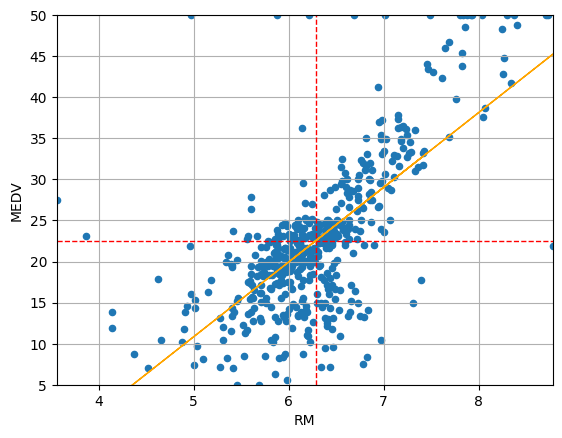

In [17]:
# Displaying again the scatterplot to plot the average value for both the target and the predictor variables as dashed lines.
x_range = [boston['RM'].min(),boston['RM'].max()]
y_range = [boston['MEDV'].min(),boston['MEDV'].max()]
scatter_plot = boston.plot(kind='scatter', x='RM', y='MEDV', xlim=x_range, ylim=y_range)
meanY = scatter_plot.plot(x_range, [boston['MEDV'].mean(),boston['MEDV'].mean()], '--', color='red', linewidth=1)
meanX = scatter_plot.plot([boston['RM'].mean(),boston['RM'].mean()], y_range, '--', color='red', linewidth=1)

# Use the predict method to project the fitted predictions on our previous scatterplot to allow us to
# visualize the price dynamics in respect of our predictor, the average number of rooms
regression_line = scatter_plot.plot(boston['RM'], fitted_values, '-', color='orange', linewidth=1)
plt.grid()
# thanks to this graphical display, we can notice that the regression line exactly passes at the intersection of the x and y averages.
# But

## Student Activity
1. EDA -  explore the dataset that has some outliers in the Dependent variable MEDV.
Extract these rows and perform some analysis to understand if there is anything of interest
2. Model: remove these rows, create another correlation matrix and a new Linear Regression model. Plot the regression line.

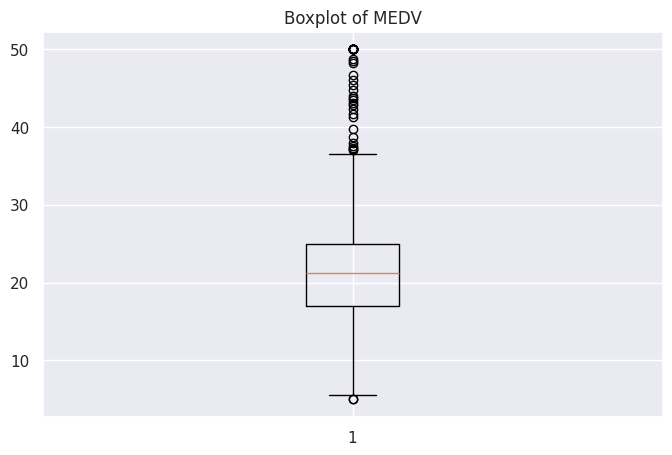

In [ ]:
plt.boxplot(boston['MEDV'])
plt.title("Boxplot of MEDV")
plt.show()

# explanation: There are many points stacked at MEDV = 50.
#Houses worth more than 50 were recorded as 50.
#So these are not natural outliers. They are artificial limits.

In [18]:
outliers = boston[boston['MEDV'] >= 50]
#print(outliers)
print(len(outliers))

16


In [ ]:
outliers.describe()


,MEDV,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
count,16.0,16.000000,16.000000,16.000000,16.000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.00000,16.000000,16.000000
mean,50.0,2.703412,19.062500,11.860625,0.375,0.566569,7.484000,77.637500,2.586087,10.625000,415.437500,16.48125,381.743125,4.355000
std,0.0,3.145228,35.129226,8.187944,0.500,0.089586,1.062342,26.934609,1.592896,9.415413,188.201654,2.88056,12.920621,2.321221
min,50.0,0.013810,0.000000,0.460000,0.000,0.401000,4.970000,24.800000,1.129600,1.000000,193.000000,13.00000,347.880000,1.730000
25%,50.0,0.409203,0.000000,3.647500,0.000,0.500000,6.932750,63.650000,1.350650,4.750000,261.750000,14.62500,375.105000,2.967500
50%,50.0,1.491190,0.000000,18.100000,0.000,0.605000,7.853000,90.200000,2.043300,5.000000,403.000000,14.70000,386.495000,3.510000
75%,50.0,5.091160,20.000000,18.470000,1.000,0.631000,8.099750,96.975000,2.970600,24.000000,666.000000,20.20000,390.925000,4.752500
max,50.0,9.232300,95.000000,19.580000,1.000,0.668000,8.725000,100.000000,5.885000,24.000000,666.000000,20.20000,395.520000,9.530000


the outlier houses have an average of over 7 rooms. These are large houses which are likely expensive.

LSTAT mean = 4.35
low value means wealthy neighborhoods.

In [ ]:
outliers.corr()

,MEDV,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
MEDV,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CRIM,NaN,1.000000,-0.480516,0.660683,0.323170,0.664180,-0.801550,0.606778,-0.680608,0.935586,0.937833,0.830326,-0.699966,0.532343
ZN,NaN,-0.480516,1.000000,-0.708856,-0.092516,-0.825824,0.292432,-0.900377,0.909537,-0.453632,-0.571222,-0.483755,0.483316,-0.230125
INDUS,NaN,0.660683,-0.708856,1.000000,0.382778,0.782721,-0.530818,0.857220,-0.775744,0.568789,0.797323,0.478030,-0.580824,-0.006276
CHAS,NaN,0.323170,-0.092516,0.382778,1.000000,0.210729,-0.154376,0.173135,-0.145657,0.272603,0.360872,0.218129,-0.016705,-0.124073
NOX,NaN,0.664180,-0.825824,0.782721,0.210729,1.000000,-0.446067,0.930544,-0.967856,0.612594,0.738956,0.422979,-0.599451,0.325462
RM,NaN,-0.801550,0.292432,-0.530818,-0.154376,-0.446067,1.000000,-0.382898,0.459807,-0.841186,-0.824432,-0.789940,0.606978,-0.270329
AGE,NaN,0.606778,-0.900377,0.857220,0.173135,0.930544,-0.382898,1.000000,-0.952348,0.574506,0.732138,0.464453,-0.533411,0.169910
DIS,NaN,-0.680608,0.909537,-0.775744,-0.145657,-0.967856,0.459807,-0.952348,1.000000,-0.654114,-0.752032,-0.541519,0.592641,-0.342571
RAD,NaN,0.935586,-0.453632,0.568789,0.272603,0.612594,-0.841186,0.574506,-0.654114,1.000000,0.946000,0.906502,-0.592577,0.406889


The MEDV variable has no variance among the outliers because all values are capped at 50. As a result, correlations cannot be computed, so pyhton return NaN.

In [19]:
#removing outliers
boston_clean = boston[boston['MEDV'] != 50]

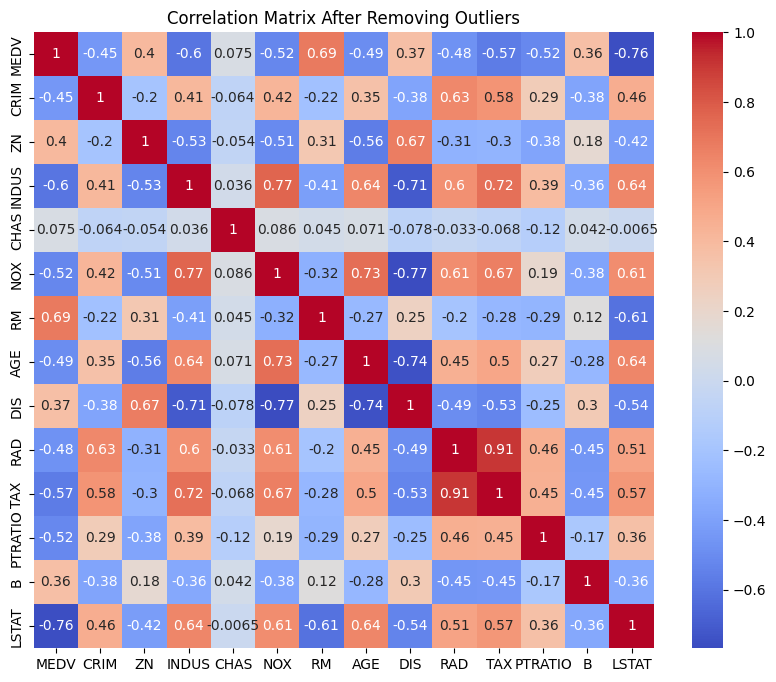

In [20]:
plt.figure(figsize=(10,8))
sns.heatmap(boston_clean.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix After Removing Outliers")
plt.show()


In [21]:
y = boston_clean['MEDV']
X = boston_clean['RM']

X = sm.add_constant(X)

linear_regression = sm.OLS(y, X)
fitted_model = linear_regression.fit()

fitted_model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   MEDV   R-squared:                       0.471
Model:                            OLS   Adj. R-squared:                  0.470
Method:                 Least Squares   F-statistic:                     435.3
Date:                Sun, 08 Feb 2026   Prob (F-statistic):           1.41e-69
Time:                        01:13:20   Log-Likelihood:                -1549.2
No. Observations:                 490   AIC:                             3102.
Df Residuals:                     488   BIC:                             3111.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -30.0051      2.489    -12.057      0.000     -34.895     -25.115
RM             8.2686      0.396     20.864      0.000       7.490       9.047
==============================================================================
Omnibus:                       31.483   Durbin-Watson:                   0.762
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               90.040
Skew:                          -0.239   Prob(JB):                     2.81e-20
Kurtosis:                       5.045   Cond. No.                         61.9
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [22]:
fitted_values = fitted_model.predict(X)

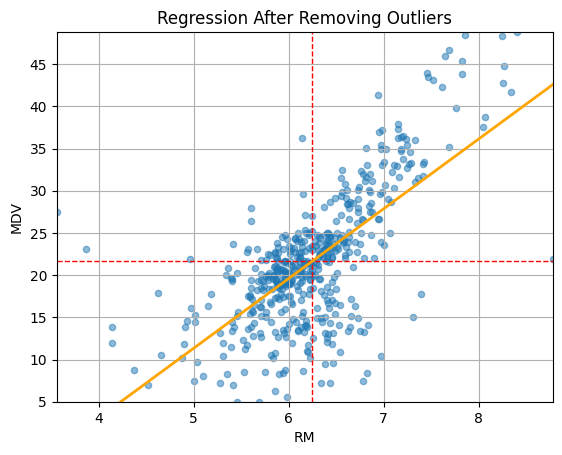

In [23]:
x_range = [boston_clean['RM'].min(), boston_clean['RM'].max()]
y_range = [boston_clean['MEDV'].min(), boston_clean['MEDV'].max()]

scatter_plot = boston_clean.plot(kind='scatter', x='RM', y='MEDV',
                                 xlim=x_range, ylim=y_range,
                                 alpha=0.5)

# mean lines (red)
meanY = scatter_plot.plot(x_range,
                          [boston_clean['MEDV'].mean(), boston_clean['MEDV'].mean()],
                          '--', color='red', linewidth=1)
meanX = scatter_plot.plot([boston_clean['RM'].mean(), boston_clean['RM'].mean()],
                          y_range, '--', color='red', linewidth=1)

# regression line (orange)
sorted_index = np.argsort(boston_clean['RM'])
x_sorted = boston_clean['RM'].iloc[sorted_index]
y_sorted = fitted_values.iloc[sorted_index]

regression_line = scatter_plot.plot(x_sorted, y_sorted,
                                     '-', color='orange', linewidth=2)

plt.xlabel("RM")
plt.ylabel("MDV")
plt.title("Regression After Removing Outliers")

plt.grid()

plt.show()